In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "D:/datathon-2026-round-1/data/raw/"

ACCENT  = '#ff4d6d'   # red  — loss / bad
OK      = '#43e97b'   # green — profit / good
BLUE    = '#4895ef'   # blue  — neutral
YELLOW  = '#ffd166'   # yellow — highlight

In [14]:
print("Loading datasets...")

df_orders      = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
df_order_items = pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
df_products    = pd.read_csv(DATA_DIR + "products.csv")
df_promotions  = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])
df_customers   = pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
df_geography   = pd.read_csv(DATA_DIR + "geography.csv")
df_payments    = pd.read_csv(DATA_DIR + "payments.csv")
df_returns     = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
df_reviews     = pd.read_csv(DATA_DIR + "reviews.csv", parse_dates=["review_date"])
df_shipments   = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date", "delivery_date"])
df_inventory   = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])
df_web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
df_sales       = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

print("All datasets loaded.\n")

Loading datasets...
All datasets loaded.



> Tính toán cho mục đích phân tích doanh thu

In [15]:
items = (
    df_order_items
    .merge(df_products[['product_id','category','segment','cogs','price']], on='product_id', how='left')
    .merge(df_orders[['order_id','order_date','customer_id','order_status']], on='order_id', how='left')
)

# Adds cost metric
items['gross_demand']   = items['unit_price']  * items['quantity']          # Qty × UnitPrice
items['net_revenue']    = items['gross_demand'] - items['discount_amount']  # sau giảm giá
items['total_cogs']     = items['cogs']         * items['quantity']          # Qty × COGS
items['gross_profit']   = items['net_revenue']  - items['total_cogs']        # lãi/lỗ thực
items['margin_pct']     = items['gross_profit'] / items['net_revenue']       # biên lợi nhuận
items['discount_rate']  = items['discount_amount'] / items['gross_demand']   # % giảm giá thực

# promo_flag: đơn có ít nhất 1 mã KM
items['promo_flag'] = (items['promo_id'].notna() | items['promo_id_2'].notna()).astype(int)

print(f'Tổng số items: {len(items):,}')
print(f'Số lượng items có áp dụng khuyến mãi: {items["promo_flag"].sum():,} ({items["promo_flag"].mean()*100:.1f}%)')
items.head(3)

Tổng số items: 714,669
Số lượng items có áp dụng khuyến mãi: 276,316 (38.7%)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,category,segment,cogs,...,order_date,customer_id,order_status,gross_demand,net_revenue,total_cogs,gross_profit,margin_pct,discount_rate,promo_flag
0,1,2400,7,1138.22,0.0,NaN,NaN,GenZ,Trendy,1053.798008,...,2012-07-04,58578,delivered,7967.54,7967.54,7376.586059,590.953941,0.074170,0.0,0
1,2,609,7,10166.25,0.0,NaN,NaN,Streetwear,Everyday,8987.704231,...,2012-07-04,58621,returned,71163.75,71163.75,62913.929616,8249.820384,0.115927,0.0,0
2,3,396,3,11220.33,0.0,NaN,NaN,Streetwear,Balanced,10091.012256,...,2012-07-04,58811,delivered,33660.99,33660.99,30273.036767,3387.953233,0.100649,0.0,0


In [16]:
items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'promo_id', 'promo_id_2', 'category', 'segment', 'cogs', 'price',
       'order_date', 'customer_id', 'order_status', 'gross_demand',
       'net_revenue', 'total_cogs', 'gross_profit', 'margin_pct',
       'discount_rate', 'promo_flag'],
      dtype='object')

## [001 - Verify problem]

> #### Overall 

In [17]:
overall = {
    'gross_demand':  items['gross_demand'].sum(),
    'net_revenue':   items['net_revenue'].sum(),
    'total_cogs':    items['total_cogs'].sum(),
    'discount_amt':  items['discount_amount'].sum(),
    'gross_profit':  items['gross_profit'].sum(),
}
overall['margin_pct'] = overall['gross_profit'] / overall['net_revenue']

pd.DataFrame([overall]).style.format({
    'gross_demand': '{:,.0f}', 'net_revenue': '{:,.0f}',
    'total_cogs':   '{:,.0f}', 'discount_amt':'{:,.0f}',
    'gross_profit': '{:,.0f}', 'margin_pct':  '{:.2%}'
})


,gross_demand,net_revenue,total_cogs,discount_amt,gross_profit,margin_pct
0,"16,430,476,586","15,680,869,265","14,163,450,519","749,607,320","1,517,418,746",9.68%


In [18]:
items['year'] = items['order_date'].dt.year
yearly_revenue = items.groupby('year').agg(
num_items     = ('order_id',       'size'),
gross_demand  = ('gross_demand',   'sum'),
discount_amt  = ('discount_amount','sum'),
net_revenue   = ('net_revenue',    'sum'),
total_cogs    = ('total_cogs',     'sum'),
gross_profit  = ('gross_profit',   'sum'),
).reset_index()
yearly_revenue

,year,num_items,gross_demand,discount_amt,net_revenue,total_cogs,gross_profit
0,2012,37007,7.414977e+08,0.00,7.414977e+08,5.874619e+08,1.540358e+08
1,2013,87341,1.657169e+09,87004248.57,1.570165e+09,1.465980e+09,1.041851e+08
2,2014,91086,1.871846e+09,86503167.66,1.785343e+09,1.574607e+09,2.107353e+08
3,2015,92537,1.889934e+09,97923860.36,1.792010e+09,1.665442e+09,1.265681e+08
4,2016,90895,2.104641e+09,92276211.92,2.012364e+09,1.780559e+09,2.318051e+08
5,2017,83691,1.911164e+09,95617691.30,1.815547e+09,1.694386e+09,1.211608e+08
6,2018,75132,1.850122e+09,80399276.46,1.769723e+09,1.542176e+09,2.275474e+08
7,2019,44925,1.136801e+09,55211860.32,1.081590e+09,1.005203e+09,7.638670e+07
8,2020,37238,1.054512e+09,48403622.41,1.006109e+09,8.860851e+08,1.200234e+08
9,2021,36749,1.043040e+09,51825645.91,9.912142e+08,9.411301e+08,5.008405e+07


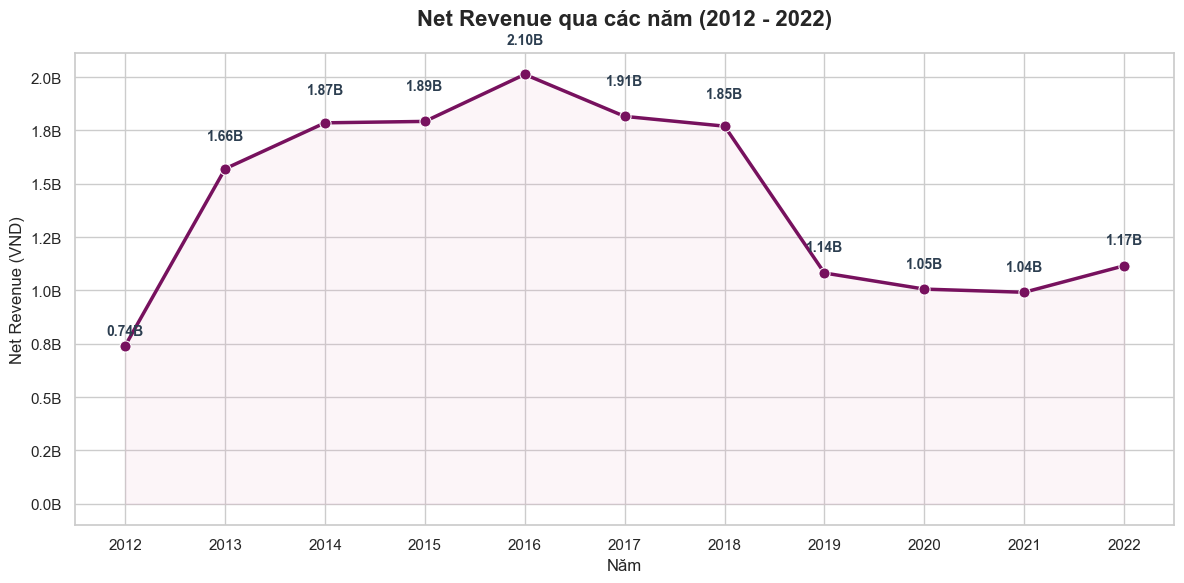

In [56]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
line_plot = sns.lineplot(
    data=yearly_revenue, x='year', y='net_revenue', 
    marker='o', markersize=8, linewidth=2.5, color="#77115e"
)

plt.fill_between(yearly_revenue['year'], yearly_revenue['net_revenue'], color="#eba2c4", alpha=0.1)

# 5. Định dạng tiêu đề và nhãn
plt.title('Net Revenue qua các năm (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Net Revenue (VND)', fontsize=12)

def format_billions(x, pos):
    return f'{x/1e9:.1f}B'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_billions))

for i in range(yearly_revenue.shape[0]):
    plt.text(
        yearly_revenue.year[i], yearly_revenue.gross_demand[i] + 5e7, 
        f'{yearly_revenue.gross_demand[i]/1e9:.2f}B', 
        ha='center', fontsize=10, fontweight='bold', color='#2c3e50'
    )

plt.xticks(yearly_revenue['year']) 
plt.tight_layout()
plt.show()

Tỷ suất lợi nhuận rất mỏng so với 1 doanh nghiệp bán hàng thời trang. Chưa kể đến các chi phí vận hành, logistic, marketing thì có thể nói doanh nghiệp này đang bán để hòa vốn hoặc thậm chí lỗ

> #### Promotion vs. No-Promotion

In [20]:

t2 = items.groupby('promo_flag').agg(
    num_items     = ('order_id',       'size'),
    gross_demand  = ('gross_demand',   'sum'),
    discount_amt  = ('discount_amount','sum'),
    net_revenue   = ('net_revenue',    'sum'),
    total_cogs    = ('total_cogs',     'sum'),
    gross_profit  = ('gross_profit',   'sum'),
).assign(
    margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
    avg_discount_rate = lambda d: d['discount_amt'] / d['gross_demand']
)
t2.index = ['No Promo', 'Promo']
print('=== PROMO vs NON-PROMO ===')
t2.style.format({
    'num_items':'{:,.0f}', 'gross_demand':'{:,.0f}', 'discount_amt':'{:,.0f}',
    'net_revenue':'{:,.0f}','total_cogs':'{:,.0f}',  'gross_profit':'{:,.0f}',
    'margin_pct':'{:.2%}', 'avg_discount_rate':'{:.2%}'
}).applymap(lambda x: 'color: #ff4d6d' if isinstance(x,float) and x < 0 else '',
            subset=['gross_profit','margin_pct'])

=== PROMO vs NON-PROMO ===


,num_items,gross_demand,discount_amt,net_revenue,total_cogs,gross_profit,margin_pct,avg_discount_rate
No Promo,"438,353","10,995,039,053",0,"10,995,039,053","8,800,023,667","2,195,015,386",19.96%,0.00%
Promo,"276,316","5,435,437,533","749,607,320","4,685,830,213","5,363,426,852","-677,596,639",-14.46%,13.79%


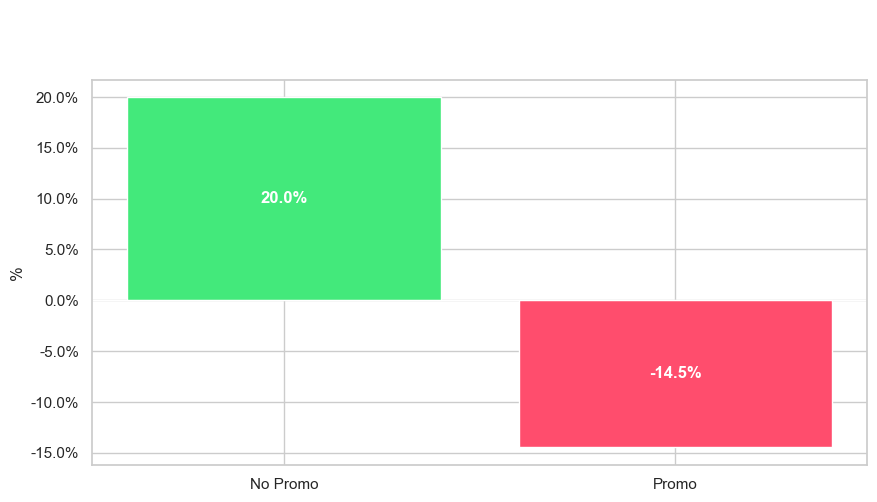

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Promo vs Non-Promo: Doanh thu & Lợi nhuận', fontsize=14, color='white', y=1.02)

groups   = ['No Promo', 'Promo']
colors_p = [OK, ACCENT]

# Left: Margin %
bars = ax.bar(groups, t2['margin_pct']*100,
              color=[OK if v > 0 else ACCENT for v in t2['margin_pct']])
ax.axhline(0, color='white', lw=0.8)
ax.set_title('Profit Margin %', color='white')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, t2['margin_pct']):
    y_pos = bar.get_height() / 2 
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{val*100:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)


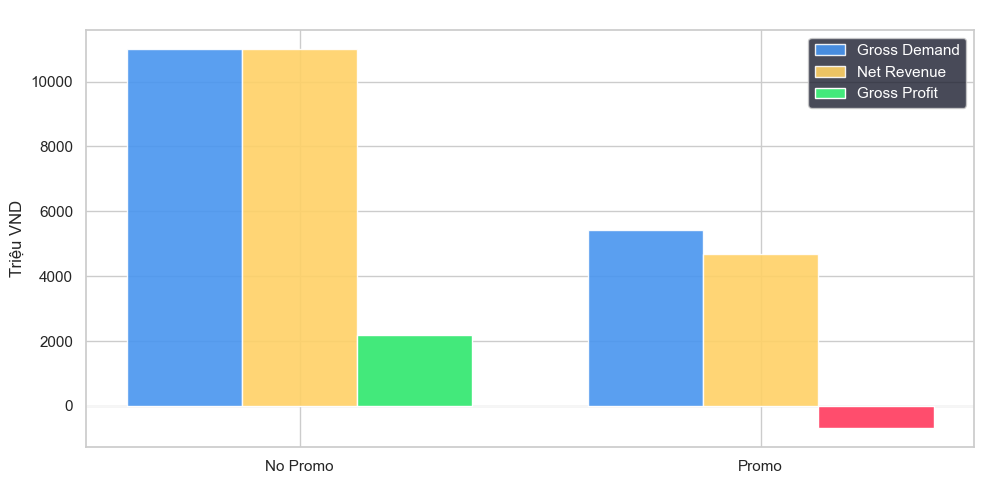

In [22]:
fig, ax= plt.subplots(figsize=(10,5))
x  = np.arange(2)
w  = 0.25
ax.bar(x - w, t2['gross_demand']/1e6,  width=w, label='Gross Demand', color=BLUE,   alpha=0.9)
ax.bar(x,     t2['net_revenue']/1e6,   width=w, label='Net Revenue',  color=YELLOW, alpha=0.9)
ax.bar(x + w, t2['gross_profit']/1e6,  width=w, label='Gross Profit', 
        color=[OK if v>0 else ACCENT for v in t2['gross_profit']])
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_title('Revenue Breakdown (triệu VND)', color='white')
ax.set_ylabel('Triệu VND')
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.axhline(0, color='white', lw=0.6)

plt.tight_layout()
plt.savefig('t2_promo_vs_nonpromo.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

Có thể thấy việc áp dụng mã giảm giá làm cho doang nghiệp đang lỗ nặng, dẫn đến lãi suất âm

> Deeper into categories

*All items*

In [23]:
cate_df = items[['order_id','category','net_revenue', 'gross_profit']].copy()
summary_display = cate_df.groupby('category').agg({
    'order_id': 'size',
    'net_revenue': 'sum',
    'gross_profit': 'sum',
})
summary_display['margin_profit'] = (summary_display['gross_profit'] / summary_display['net_revenue'])
summary_display = summary_display.rename(columns={'order_id': 'num_of_items'})
formatted_summary = summary_display.style.format({
    'num_of_items': '{:,.0f}',
    'net_revenue': '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'margin_profit': '{:.2%}',
}).applymap(lambda x: 'color: red' if x < 0 else '', subset=['gross_profit'])

formatted_summary


,num_of_items,net_revenue,gross_profit,margin_profit
category,,,,
Casual,"23,991","440,285,194","33,740,765",7.66%
GenZ,"37,159","328,710,176","50,836,377",15.47%
Outdoor,"259,986","2,353,396,797","267,034,092",11.35%
Streetwear,"393,533","12,558,477,099","1,165,807,512",9.28%


*Promotion only*

In [24]:
promo_cate_df = items[items['promo_flag']==1][['order_id','category','net_revenue','gross_profit']]
summary_display = promo_cate_df.groupby('category').agg({
    'order_id':    'size',
    'net_revenue': 'sum',
    'gross_profit':'sum',
})
summary_display['margin_profit'] = summary_display['gross_profit'] / summary_display['net_revenue']
summary_display = summary_display.rename(columns={'order_id':'num_of_items'})

summary_display.style.format({
    'num_of_items': '{:,.0f}',
    'net_revenue':  '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'margin_profit':'{:.2%}',      
}).map(lambda x: 'color: red'   if isinstance(x, float) and x < 0 else
                 'color: green' if isinstance(x, float) and x > 0 else '',
       subset=['gross_profit','margin_profit'])

,num_of_items,net_revenue,gross_profit,margin_profit
category,,,,
Casual,"8,075","118,328,330","-18,354,209",-15.51%
GenZ,"12,232","85,899,805","-4,937,656",-5.75%
Outdoor,"108,341","764,184,900","-75,649,349",-9.90%
Streetwear,"147,668","3,717,417,177","-578,655,426",-15.57%


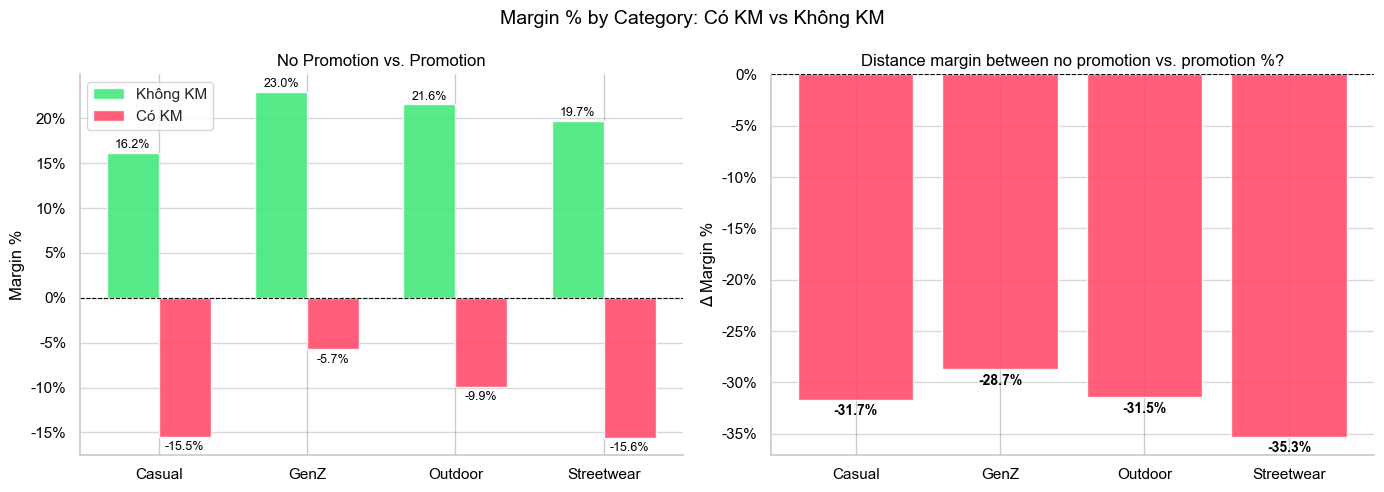

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Margin % by Category: Có KM vs Không KM', fontsize=14, color='black')

# Data không KM
no_promo = items[items['promo_flag']==0].groupby('category').agg(
    net_revenue  = ('net_revenue',  'sum'),
    gross_profit = ('gross_profit', 'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

# Data có KM
with_promo = items[items['promo_flag']==1].groupby('category').agg(
    net_revenue  = ('net_revenue',  'sum'),
    gross_profit = ('gross_profit', 'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

categories = no_promo.index.tolist()
x = np.arange(len(categories))
w = 0.35

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors='black')


ax = axes[0]
ax.bar(x - w/2, no_promo['margin_pct']*100,  width=w, color=OK,    label='Không KM', alpha=0.9)
ax.bar(x + w/2, with_promo['margin_pct']*100, width=w, color=ACCENT, label='Có KM',    alpha=0.9)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(categories, color='black')
ax.set_ylabel('Margin %', color='black')
ax.set_title('No Promotion vs. Promotion', color='black')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend()
ax.grid(axis='y', alpha=0.3, color='gray')

# Annotate
for i, (nv, wv) in enumerate(zip(no_promo['margin_pct'], with_promo['margin_pct'])):
    ax.text(i - w/2, nv*100 + 0.5, f'{nv*100:.1f}%', ha='center', fontsize=9, color='black')
    ax.text(i + w/2, wv*100 - 1.5 if wv < 0 else wv*100 + 0.5,
            f'{wv*100:.1f}%', ha='center', fontsize=9, color='black')


ax2 = axes[1]
delta = (with_promo['margin_pct'] - no_promo['margin_pct']) * 100
bar_c = [ACCENT if v < 0 else OK for v in delta]
bars = ax2.bar(categories, delta, color=bar_c, alpha=0.9)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Distance margin between no promotion vs. promotion %?', color='black')
ax2.set_ylabel('Δ Margin %', color='black')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.grid(axis='y', alpha=0.3, color='gray')
ax2.tick_params(colors='black')

for bar, val in zip(bars, delta):
    y_pos = val - 1.5 if val < 0 else val + 0.3
    ax2.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:+.1f}%', ha='center', fontsize=10,
             color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('category_margin_compare.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

* Khuyến mãi đang biến lợi nhuận âm thành âm trong tất cả các categories -> khuyến mãi chính là nguyên nhân làm doanh nghiệp thua lỗ

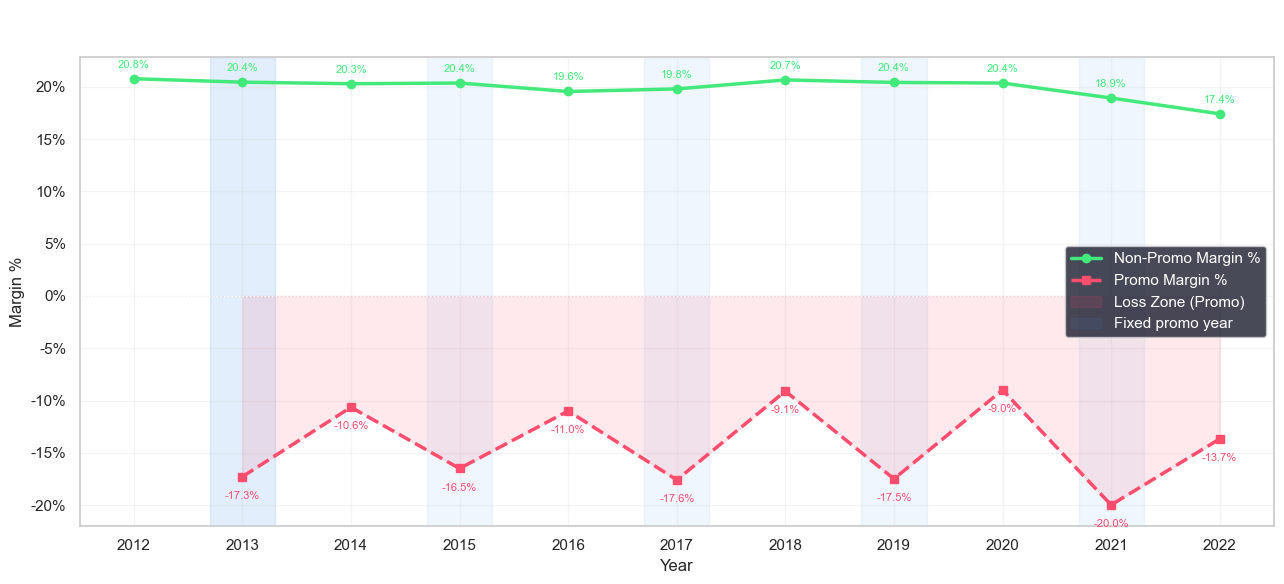

In [26]:
t3 = items.groupby(['year','promo_flag']).agg(
    net_revenue  = ('net_revenue',   'sum'),
    gross_profit = ('gross_profit',  'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

df_compare = t3['margin_pct'].unstack('promo_flag')
df_compare.columns = ['Non-Promo', 'Promo']
df_compare = df_compare.sort_index()

fixed_years = [yr for yr in df_compare.index 
               if yr in df_promotions[df_promotions['promo_type']=='fixed']['start_date'].dt.year.values]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_compare.index, df_compare['Non-Promo'] * 100,
        marker='o', color=OK,    label='Non-Promo Margin %', lw=2.5)
ax.plot(df_compare.index, df_compare['Promo'] * 100,
        marker='s', color=ACCENT, label='Promo Margin %',    lw=2.5, linestyle='--')

ax.fill_between(df_compare.index, df_compare['Promo'] * 100, 0,
                where=(df_compare['Promo'] < 0),
                color=ACCENT, alpha=0.12, label='Loss Zone (Promo)')

for yr in fixed_years:
    ax.axvspan(yr - 0.3, yr + 0.3, alpha=0.08, color=BLUE, zorder=0)
if fixed_years:
    ax.axvspan(fixed_years[0] - 0.3, fixed_years[0] + 0.3,
               alpha=0.08, color=BLUE, zorder=0, label='Fixed promo year')

for yr, val in df_compare['Promo'].items():
    ax.annotate(f'{val*100:.1f}%',
                xy=(yr, val*100),
                xytext=(0, -16), textcoords='offset points',
                ha='center', fontsize=8, color=ACCENT)

for yr, val in df_compare['Non-Promo'].items():
    ax.annotate(f'{val*100:.1f}%',
                xy=(yr, val*100),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color=OK)

ax.axhline(0, color='white', lw=1, linestyle=':')
ax.set_title('Tầng 3 — Margin % theo năm: Promo vs Non-Promo\n'
             '(vùng xanh = năm có fixed promo, vùng đỏ = loss zone)',
             color='white', fontsize=13)
ax.set_ylabel('Margin %')
ax.set_xlabel('Year')
ax.set_xticks(df_compare.index)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('t3_margin_by_year.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

* Biên lợi nhuận cho các sản phẩm khuyến mãi ổn định quanh 20% trong suốt giai đoạn 2012–2020, chứng minh sản phẩm hoàn toàn có khả năng sinh lời. 
* Nhưng chính khuyến mãi là nguyên nhân đem lại biên lợi nhuận âm nựang, dao động -9% đến -20%, không có năm nào thoát khỏi vùng đỏ.
* Một pattern thú vị được phát hiện là những năm có fix promotion sẽ lỗ nặng hơn những năm chỉ có các chiến dịch percentage promotion

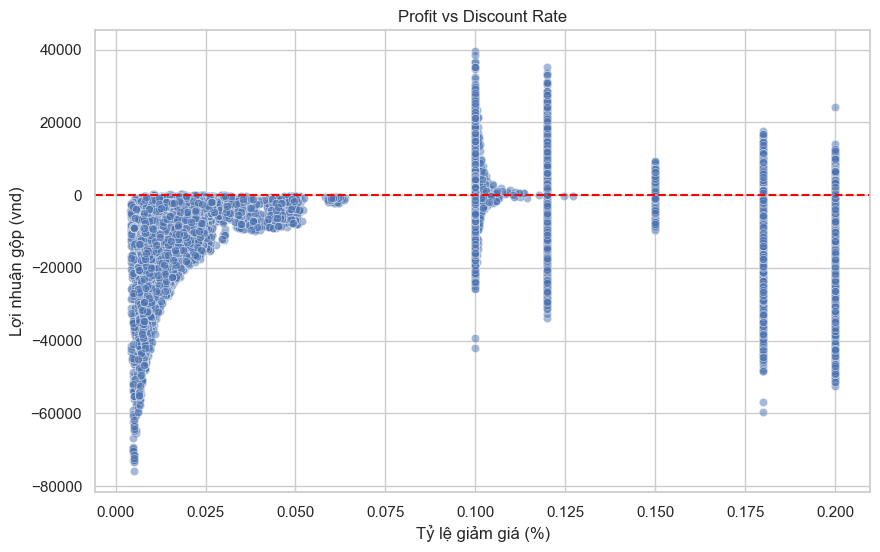

Mức giảm giá an toàn trung bình: 14.13%


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
sns.scatterplot(data=items[items['promo_flag']==1], x='discount_rate', y='gross_profit', alpha=0.5)
plt.axhline(0, color='red', linestyle='--') 
plt.title('Profit vs Discount Rate')
plt.xlabel('Tỷ lệ giảm giá (%)')
plt.ylabel('Lợi nhuận gộp (vnd)')
plt.show()

safe_discount = items[(items['promo_flag']==1) & (items['gross_profit'] > 0)]['discount_rate'].mean()
print(f"Mức giảm giá an toàn trung bình: {safe_discount:.2%}")

In [28]:
df_loss = items[items['cogs'] > items['unit_price']][['price', 'unit_price', 'cogs']]
df_loss.head(5)

,price,unit_price,cogs
77,7240.102907,6747.15,6878.097762
2548,1341.312712,1274.04,1274.247076
3242,7240.102907,6815.42,6878.097762
3300,1109.261061,1045.43,1053.798008
4189,9014.516341,8538.57,8563.790524


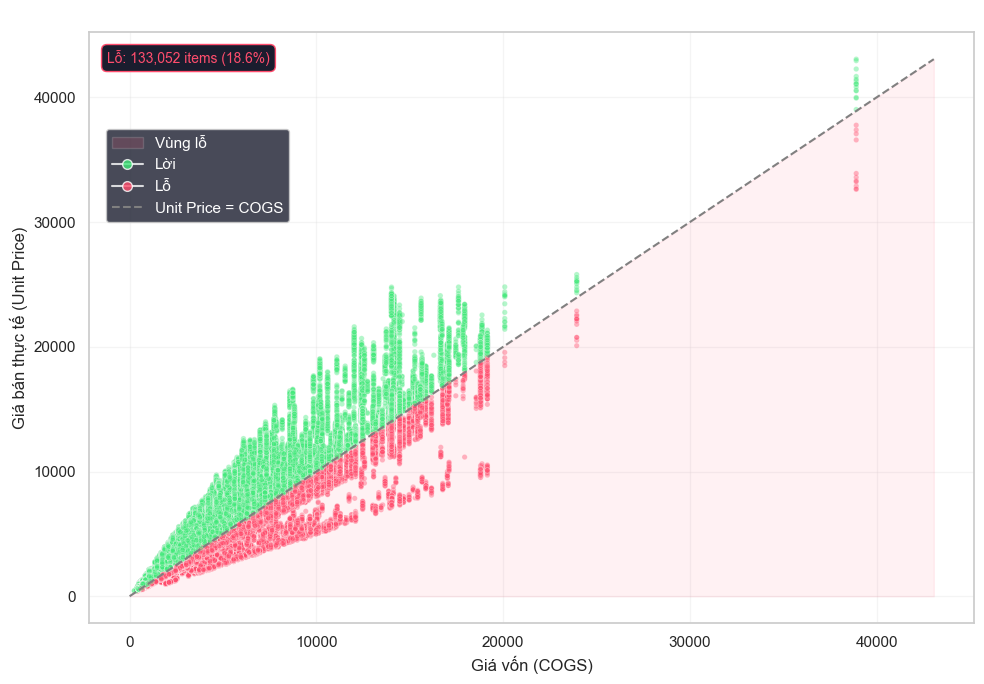

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
df_copy = items.copy()
df_copy['profit_status'] = np.where(df_copy['unit_price'] >= df_copy['cogs'], 'Lời', 'Lỗ')

max_val = max(df_copy['cogs'].max(), df_copy['unit_price'].max())

ax.fill_between([0, max_val], 0, [0, max_val], color=ACCENT, alpha=0.08)

sns.scatterplot(
    data=df_copy, x='cogs', y='unit_price',
    hue='profit_status',
    palette={'Lời': OK, 'Lỗ': ACCENT},
    alpha=0.4, s=15, ax=ax,
    legend=False          
)

ax.plot([0, max_val], [0, max_val], color='grey', linestyle='--',
        lw=1.5, zorder=5)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=ACCENT, alpha=0.15, label='Vùng lỗ'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=OK,
           markersize=7, label='Lời', alpha=0.8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=ACCENT,
           markersize=7, label='Lỗ', alpha=0.8),
    Line2D([0],[0], color='grey', linestyle='--', lw=1.5, label='Unit Price = COGS'),
]
ax.legend(handles=handles, facecolor='#1a1d2e', labelcolor='white',
          loc='upper left', bbox_to_anchor=(0.01, 0.85))  # đẩy xuống tránh text box

n_loss = (df_copy['profit_status'] == 'Lỗ').sum()
n_total = len(df_copy)
ax.text(0.02, 0.97,
        f'Lỗ: {n_loss:,} items ({n_loss/n_total*100:.1f}%)',
        transform=ax.transAxes, fontsize=10,
        color=ACCENT, va='top',
        bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT, boxstyle='round,pad=0.4'))

ax.set_title('Unit Price vs COGS — The Loss Zone', color='white', fontsize=13)
ax.set_xlabel('Giá vốn (COGS)')
ax.set_ylabel('Giá bán thực tế (Unit Price)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('loss_zone_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [30]:
df_fail = items[items['cogs'] > items['unit_price']][items['promo_flag']==0]

overall = {
    'gross_demand':  df_fail['gross_demand'].sum(),
    'net_revenue':   df_fail['net_revenue'].sum(),
    'total_cogs':    df_fail['total_cogs'].sum(),
    'discount_amt':  df_fail['discount_amount'].sum(),
    'gross_profit':  df_fail['gross_profit'].sum(),
}
overall['margin_pct'] = overall['gross_profit'] / overall['net_revenue']

print(f'Items bán dưới giá vốn (không có KM): {len(df_fail):,}')
print(f'Gross profit: {df_fail["gross_profit"].sum():,.0f}')

pd.DataFrame([overall]).style.format({
    'gross_demand': '{:,.0f}', 'net_revenue': '{:,.0f}',
    'total_cogs':   '{:,.0f}', 'discount_amt':'{:,.0f}',
    'gross_profit': '{:,.0f}', 'margin_pct':  '{:.2%}'
})

Items bán dưới giá vốn (không có KM): 808
Gross profit: -137,149


,gross_demand,net_revenue,total_cogs,discount_amt,gross_profit,margin_pct
0,"19,429,538","19,429,538","19,566,687",0,"-137,149",-0.71%


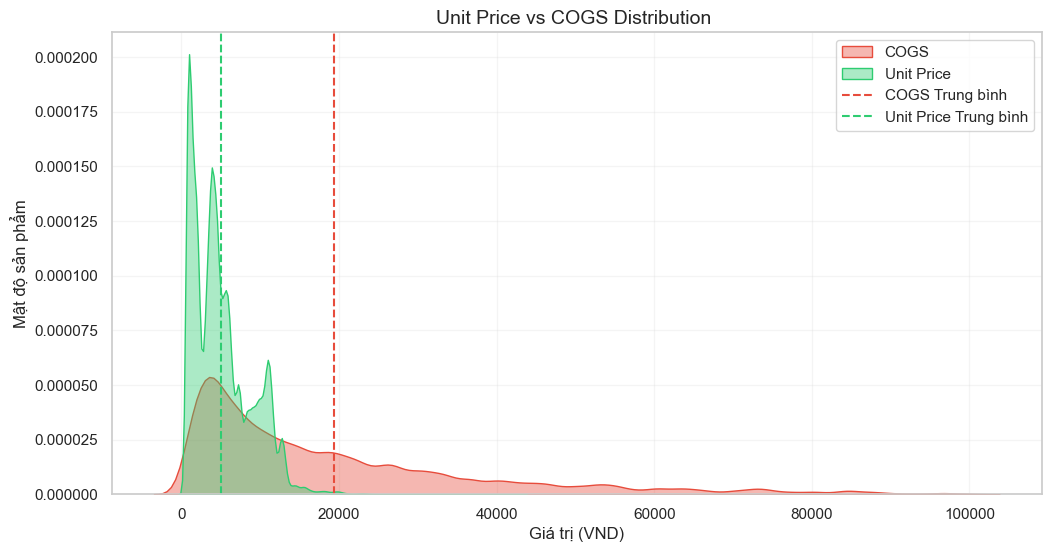

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

df_sub = items[items['total_cogs'] < 100000].copy()

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df_sub, x='total_cogs', fill=True, color='#e74c3c', label='COGS', alpha=0.4)

sns.kdeplot(data=df_sub, x='unit_price', fill=True, color='#2ecc71', label='Unit Price', alpha=0.4)

plt.axvline(df_sub['total_cogs'].mean(), color='#e74c3c', linestyle='--', label='COGS Trung bình')
plt.axvline(df_sub['unit_price'].mean(), color='#2ecc71', linestyle='--', label='Unit Price Trung bình')

plt.title('Unit Price vs COGS Distribution ', fontsize=14)
plt.xlabel('Giá trị (VND)')
plt.ylabel('Mật độ sản phẩm')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

**Phân tích phân phối cho thấy một nghịch lý tài chính nghiêm trọng**:

Hiện tượng: Giá bán thực tế (Unit Price) tập trung ở ngưỡng cực thấp, trong khi Giá vốn (COGS) phân bổ ở ngưỡng cao hơn gấp nhiều lần.

Nguyên nhân: Đây là hệ quả của việc định giá gốc (Base Pricing) sai lệch hoàn toàn so với chi phí nhập hàng, làm cho sản phẩm chưa áp dụng giảm giá đã được bán thấp hơn giá gốc, gây lỗ cho doanh nghiệp
Nguyên nhân gây lỗ ko chỉ xuất phát từ promotion

### Other reasons?

In [32]:
# ── Bước 1: Identify sản phẩm có unit_price < cogs ──
underpriced = items[items['unit_price'] < items['cogs']].copy()
underpriced['loss_per_unit'] = underpriced['cogs'] - underpriced['unit_price']
underpriced['loss_total']    = underpriced['loss_per_unit'] * underpriced['quantity']

print(f'Số line items bán dưới giá vốn : {len(underpriced):,}')
print(f'Tỷ lệ                          : {len(underpriced)/len(items):.2%}')
print(f'Tổng lỗ từ nhóm này            : {underpriced["loss_total"].sum():,.0f} VND')
print(f'Margin trung bình              : {underpriced["gross_profit"].sum()/underpriced["net_revenue"].sum():.2%}')

# ── Bước 2: Phân tích theo category và segment ──
print('\n=== UNDERPRICED BY CATEGORY ===')
cat_under = underpriced.groupby('category').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_cat = lambda d: d['num_items'] / underpriced.groupby('category').size().sum()
).sort_values('loss_total', ascending=False)

cat_under.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_cat':    '{:.2%}',
})

Số line items bán dưới giá vốn : 133,052
Tỷ lệ                          : 18.62%
Tổng lỗ từ nhóm này            : 461,536,686 VND
Margin trung bình              : -34.60%

=== UNDERPRICED BY CATEGORY ===


,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_cat
category,,,,,,,
Streetwear,"80,711","408,802,189","1,124","6,244","7,368",1.18x,60.66%
Outdoor,"43,603","41,047,155",209,"2,045","2,254",1.10x,32.77%
Casual,"5,209","8,219,813",359,"3,506","3,865",1.10x,3.92%
GenZ,"3,529","3,467,528",222,"2,313","2,535",1.10x,2.65%


In [33]:
df_orders[['order_id','order_date']]

,order_id,order_date
0,1,2012-07-04
1,2,2012-07-04
2,3,2012-07-04
3,4,2012-07-04
4,6,2012-07-06
...,...,...
646940,834372,2022-12-31
646941,834377,2022-12-31
646942,834387,2022-12-31
646943,834392,2022-12-31


In [34]:
# # 1. Đảm bảo order_date đúng định dạng
# df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# # 2. Merge và tính toán theo năm
# time_underprice = underpriced.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
# time_underprice['order_year'] = time_underprice['order_date'].dt.year

# 3. Tổng hợp dữ liệu
yearly_summary = underpriced.groupby('year').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_total_loss_items = lambda d: d['num_items'] / len(underpriced) 
).sort_values('year')

# 4. Hiển thị bảng đẹp để copy vào Doc
yearly_summary.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_total_loss_items': '{:.2%}',
})

,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_total_loss_items
year,,,,,,,
2012,73,"9,700",29,"4,030","4,059",1.01x,0.05%
2013,"20,853","75,820,748",804,"3,704","4,508",1.22x,15.67%
2014,"14,912","25,911,055",386,"3,997","4,384",1.10x,11.21%
2015,"20,441","80,802,486",873,"4,142","5,016",1.21x,15.36%
2016,"13,763","29,541,183",479,"4,897","5,376",1.10x,10.34%
2017,"19,274","84,927,167",981,"4,576","5,556",1.21x,14.49%
2018,"10,636","22,837,218",477,"5,006","5,483",1.10x,7.99%
2019,"10,739","53,224,632","1,090","4,884","5,974",1.22x,8.07%
2020,"6,152","15,549,546",563,"5,895","6,458",1.10x,4.62%


In [35]:
print('\n=== UNDERPRICED BY PRODUCT ===')
cat_under = underpriced.groupby('product_id').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_prod = lambda d: d['num_items'] / underpriced.groupby('category').size().sum()
).sort_values('loss_total', ascending=False)[:15]

cat_under.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_prod':    '{:.2%}',
})


=== UNDERPRICED BY PRODUCT ===


,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_prod
product_id,,,,,,,
826,"2,446","20,019,265","1,823","10,271","12,094",1.18x,1.84%
491,"2,022","14,096,189","1,572","8,935","10,507",1.18x,1.52%
506,"1,337","12,514,532","2,137","12,326","14,463",1.17x,1.00%
487,"1,595","12,210,579","1,624","9,404","11,028",1.17x,1.20%
927,"2,704","11,164,727",916,"4,651","5,567",1.20x,2.03%
2054,"2,088","9,336,517","1,009","5,709","6,718",1.18x,1.57%
2055,"1,825","8,688,560","1,067","5,811","6,878",1.18x,1.37%
551,"1,096","8,631,906","1,715","8,968","10,683",1.19x,0.82%
407,665,"8,308,837","2,715","16,075","18,790",1.17x,0.50%


In [36]:
print('=== UNDERPRICED: PROMO vs NON-PROMO ===')
under_promo = underpriced.groupby('promo_flag').agg(
    num_items  = ('order_id',    'size'),
    loss_total = ('loss_total',  'sum'),
).rename(index={0:'No Promo', 1:'Promo'})
under_promo['pct'] = under_promo['num_items'] / under_promo['num_items'].sum()
display(under_promo.style.format({
    'num_items': '{:,.0f}', 'loss_total': '{:,.0f}', 'pct': '{:.2%}'
}))

=== UNDERPRICED: PROMO vs NON-PROMO ===


,num_items,loss_total,pct
promo_flag,,,
No Promo,808,"137,149",0.61%
Promo,"132,244","461,399,537",99.39%


In [37]:
# Xem xu hướng theo năm
print('=== UNDERPRICED TREND BY YEAR ===')
underpriced.groupby('year').agg(
    num_items  = ('order_id',   'size'),
    loss_total = ('loss_total', 'sum'),
).assign(
    pct_of_year = lambda d: d['num_items'] / items.groupby('year').size()
).style.format({
    'num_items':   '{:,.0f}',
    'loss_total':  '{:,.0f}',
    'pct_of_year': '{:.2%}',
})

=== UNDERPRICED TREND BY YEAR ===


,num_items,loss_total,pct_of_year
year,,,
2012,73,"9,700",0.20%
2013,"20,853","75,820,748",23.88%
2014,"14,912","25,911,055",16.37%
2015,"20,441","80,802,486",22.09%
2016,"13,763","29,541,183",15.14%
2017,"19,274","84,927,167",23.03%
2018,"10,636","22,837,218",14.16%
2019,"10,739","53,224,632",23.90%
2020,"6,152","15,549,546",16.52%


In [38]:
# Check min_order_value 
items_with_min = items.merge(
    df_promotions[['promo_id','min_order_value']], on='promo_id', how='left'
)
bypass = items_with_min[
    (items_with_min['min_order_value'] > 0) &
    (items_with_min['gross_demand'] < items_with_min['min_order_value'])
]

In [39]:
print(f"Số items applied promotion có min_order_value > 0: {(items_with_min['min_order_value'] > 0).sum():,}")
print(f"Số items chưa đủ min_order_value nhưng vẫn được áp dụng mã giảm giá: {len(bypass):,}")
print(f"Bypass rate: {len(bypass)/(items_with_min['min_order_value'] > 0).sum():.2%}")
print(f"Gross profit của của items applied mã giảm giá khi chưa đủ điều kiện: {bypass['gross_profit'].sum():,.0f}")
print(f"Margin của bypass items: {bypass['gross_profit'].sum()/bypass['net_revenue'].sum():.2%}")

# Xem bypass theo từng promo
bypass_by_promo = (
    bypass.merge(df_promotions[['promo_id','promo_name','promo_type','discount_value','min_order_value']], 
                 on='promo_id', how='left')
    .groupby(['promo_id','promo_name','promo_type','discount_value','min_order_value_y'])
    .agg(
        num_bypass   = ('order_id',     'size'),
        gross_profit = ('gross_profit', 'sum'),
        avg_order_val= ('gross_demand', 'mean'),
        net_revenue = ('net_revenue', 'sum')
    )
    .assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])
    .sort_values('num_bypass', ascending=False)
    .reset_index()
)
print('\n=== BYPASS BY PROMO ===')
bypass_by_promo.style.format({
    'num_bypass':   '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'avg_order_val':'{:,.0f}',
    'min_order_value_y': '{:,.0f}',
})

Số items applied promotion có min_order_value > 0: 112,544
Số items chưa đủ min_order_value nhưng vẫn được áp dụng mã giảm giá: 110,896
Bypass rate: 98.54%
Gross profit của của items applied mã giảm giá khi chưa đủ điều kiện: -385,183,667
Margin của bypass items: -22.94%

=== BYPASS BY PROMO ===


,promo_id,promo_name,promo_type,discount_value,min_order_value_y,num_bypass,gross_profit,avg_order_val,net_revenue,margin_pct
0,PROMO-0014,Year-End Sale 2015,percentage,20.000000,"150,000","11,451","-29,591,013","12,875",117948745.460000,-0.250880
1,PROMO-0010,Year-End Sale 2014,percentage,20.000000,"100,000","11,332","-25,903,726","12,235",110917693.200000,-0.233540
2,PROMO-0004,Year-End Sale 2013,percentage,20.000000,"50,000","10,673","-18,227,926","9,239",78887917.540000,-0.231061
3,PROMO-0011,Spring Sale 2015,percentage,12.000000,"100,000","9,582","-3,553,516","20,753",174996173.870000,-0.020306
4,PROMO-0028,Mid-Year Sale 2018,percentage,18.000000,"150,000","8,144","-24,912,204","21,043",140529540.330000,-0.177274
5,PROMO-0022,Mid-Year Sale 2017,percentage,18.000000,"150,000","7,506","-25,700,027","21,903",134811268.620000,-0.190637
6,PROMO-0027,Spring Sale 2018,percentage,12.000000,"100,000","7,495","-3,263,744","22,221",146558703.150000,-0.022269
7,PROMO-0009,Fall Launch 2014,percentage,10.000000,"100,000","5,630","2,563,026","20,060",101644678.860000,0.025216
8,PROMO-0025,Urban Blowout 2017,fixed,50.000000,"150,000","5,385","-57,547,467","17,330",92111084.690000,-0.624762
9,PROMO-0015,Urban Blowout 2015,fixed,50.000000,"200,000","5,072","-53,201,221","16,744",83770839.850000,-0.635080


In [40]:
double_promo = items[items['promo_id'].notna() & items['promo_id_2'].notna()]
print(f'Items dùng 2 promo: {len(double_promo):,} ({len(double_promo)/len(items)*100:.3f}%)')
print(f'Gross profit: {double_promo["gross_profit"].sum():,.0f}')
print(f'Margin: {double_promo["gross_profit"].sum()/double_promo["net_revenue"].sum():.2%}')

Items dùng 2 promo: 206 (0.029%)
Gross profit: 116,605
Margin: 2.06%


In [41]:
double_promo_detail = (
    items[items['promo_id'].notna() & items['promo_id_2'].notna()]
    .merge(df_promotions[['promo_id','promo_name','discount_value']].rename(
        columns={'promo_id':'promo_id','promo_name':'name_p1','discount_value':'disc_p1'}), 
        on='promo_id', how='left')
    .merge(df_promotions[['promo_id','promo_name','discount_value']].rename(
        columns={'promo_id':'promo_id_2','promo_name':'name_p2','discount_value':'disc_p2'}), 
        on='promo_id_2', how='left')
    .groupby(['name_p1','name_p2'])
    .agg(
        num_items    = ('order_id',     'size'),
        gross_profit = ('gross_profit', 'sum'),
        net_revenue  = ('net_revenue',  'sum'),
    )
    .assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])
    .sort_values('num_items', ascending=False)
)
display(double_promo_detail)

,,num_items,gross_profit,net_revenue,margin_pct
name_p1,name_p2,,,,
Fall Launch 2015,Urban Blowout 2015,132,-46739.656096,3454678.53,-0.013529
Fall Launch 2017,Urban Blowout 2017,74,163345.120288,2206610.47,0.074025


In [42]:
check = items[items['promo_id'].notna() & items['promo_id_2'].notna()] \
    .merge(df_promotions[['promo_id','promo_name','discount_value','stackable_flag']].rename(
        columns={'promo_id':'promo_id','promo_name':'name_p1','discount_value':'disc_p1','stackable_flag': 'flag_1'}), 
        on='promo_id', how='left') \
    .merge(df_promotions[['promo_id','promo_name','discount_value','stackable_flag']].rename( 
        columns={'promo_id':'promo_id_2','promo_name':'name_p2','discount_value':'disc_p2','stackable_flag': 'flag_2'}), 
        on='promo_id_2', how='left')
error_promo = check[(check['flag_1']==0) |  (check['flag_2']==0)].shape[0]
print(f"Số lượng items giảm giá áp dụng 2 mã khuyến mãi dù ko được phép: {error_promo} - {error_promo/double_promo.shape[0]*100}%")

Số lượng items giảm giá áp dụng 2 mã khuyến mãi dù ko được phép: 206 - 100.0%


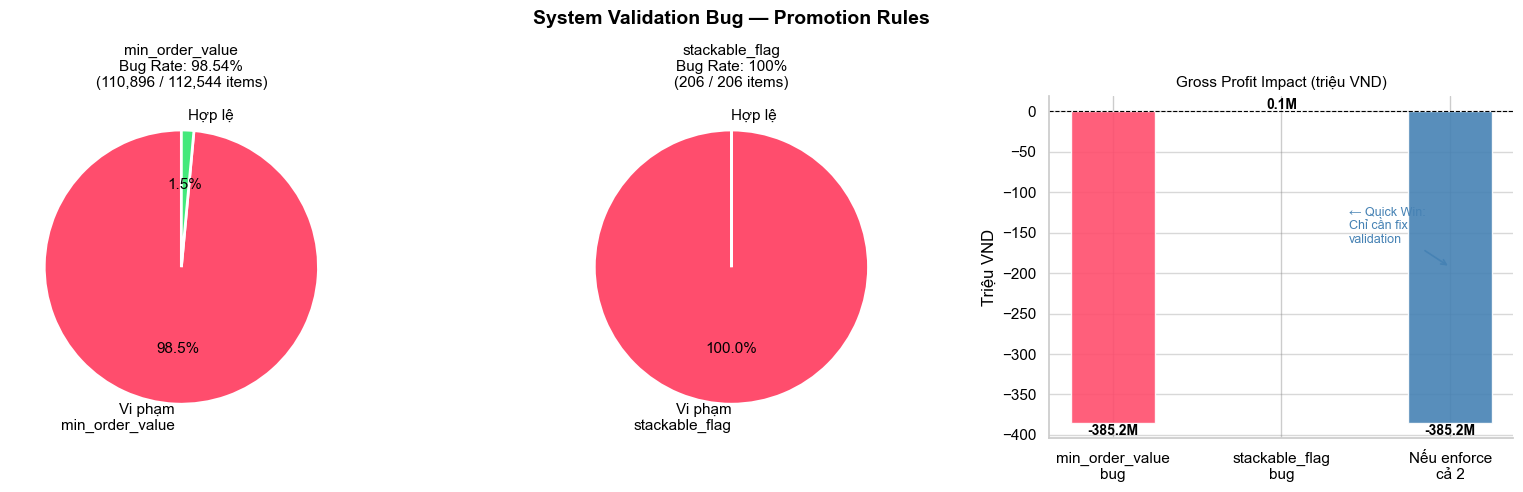

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle('System Validation Bug — Promotion Rules', 
             fontsize=14, color='black', fontweight='bold')

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)

# ── Chart 1: min_order_value bypass rate ──
ax = axes[0]
total_with_min = (items_with_min['min_order_value'] > 0).sum()
bypassed       = len(bypass)
valid          = total_with_min - bypassed

ax.pie(
    [bypassed, valid],
    labels=['Vi phạm\nmin_order_value', 'Hợp lệ'],
    colors=[ACCENT, OK],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': 'black', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title(f'min_order_value\nBug Rate: 98.54%\n({bypassed:,} / {total_with_min:,} items)', 
             color='black', fontsize=11)

# ── Chart 2: stackable_flag violation ──
ax2 = axes[1]
total_double   = len(double_promo)
valid_stack    = 0   
violated_stack = len(double_promo)

ax2.pie(
    [violated_stack, valid_stack + 0.001],  
    labels=['Vi phạm\nstackable_flag', 'Hợp lệ'],
    colors=[ACCENT, OK],
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90,
    textprops={'color': 'black', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title(f'stackable_flag\nBug Rate: 100%\n({total_double:,} / {total_double:,} items)', 
              color='black', fontsize=11)

# ── Chart 3: Gross Profit impact ──
ax3 = axes[2]
categories_bug = ['min_order_value\nbug', 'stackable_flag\nbug', 'Nếu enforce\ncả 2']
values = [
    bypass['gross_profit'].sum() / 1e6,
    double_promo['gross_profit'].sum() / 1e6,   # positive, nhỏ
    bypass['gross_profit'].sum() / 1e6,          # conservative: chỉ tính min_order
]
colors_bar = [ACCENT, OK, 'steelblue']
bars = ax3.bar(categories_bug, values, color=colors_bar, alpha=0.9, width=0.5)
ax3.axhline(0, color='black', lw=0.8, linestyle='--')
ax3.set_title('Gross Profit Impact (triệu VND)', color='black', fontsize=11)
ax3.set_ylabel('Triệu VND', color='black')
ax3.tick_params(colors='black')
ax3.grid(axis='y', alpha=0.3, color='gray')

for bar, val in zip(bars, values):
    y_pos = val - 15 if val < 0 else val + 3
    ax3.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:,.1f}M', ha='center', color='black', fontsize=10, fontweight='bold')

# Annotation "Quick Win"
ax3.annotate('← Quick Win:\nChỉ cần fix\nvalidation',
             xy=(2, values[2]/2),
             xytext=(1.4, values[2]/2 + 30),
             fontsize=9, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

plt.tight_layout()
plt.show()

### **SYSTEM VALIDATION BUG — SUMMARY**

*min_order_value không enforce |*
- bypassed items vi phạm / {total_with_min:,} items có điều kiện
- Bypass rate  : 98.54%
- Gross profit: -385,183,667 VND
- Margin: -22.94%
-------------------------------------------------------

*stackable_flag không enforce |*
- 206 items vi phạm / 206 items dùng 2 promo
- Violation rate : 100%
- Thiệt hại hiện tại : nhỏ (+2.06% margin)
- Rủi ro : nếu bị exploit với toxic promo → nguy hiểm

-------------------------------------------------------

*FIX |*
- Bật validation ở backend → recover ~385M gross profit
- Không cần thay đổi promotion strategy

=======================================================

> Khám phá độ hiểu quả của các Promotion Campaign

In [44]:
# Tập trung vào item-level để xem mã này mang lại bao nhiêu lãi thực tế và do promotion chỉ được áp dụng trên level item thôi
## Xét trên promo_id, coi như promo_id_2 chỉ là adds on, ko cân nhắc là promotion chính
promo_items = items[items['promo_id'].notna()][
    ['promo_id', 'net_revenue', 'discount_amount', 'gross_profit', 'total_cogs']
].copy()

promo_performance = promo_items.groupby('promo_id').agg(
    num_items      = ('promo_id',       'size'),
    discount_sum   = ('discount_amount','sum'),
    net_revenue    = ('net_revenue',    'sum'),
    total_cogs     = ('total_cogs',     'sum'),
    gross_profit   = ('gross_profit',   'sum'),
).assign(
    margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
    # ROI -> 1 đồng discount bỏ ra thu về bao nhiêu đồng lợi nhuận gộp
    roi = lambda d: d['gross_profit'] / d['discount_sum'],
)

top10_profitable = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit', ascending=False).head(10)

print('=== TOP 10 MOST PROFITABLE PROMOS (Lãi cao nhất) ===')
top10_profitable[['promo_id', 'promo_name', 'promo_type', 'discount_value', 
                  'num_items', 'discount_sum', 'net_revenue', 'gross_profit', 'margin_pct', 'roi']].style.format({
    'discount_value': '{:.1f}', 'num_items':   '{:,.0f}',
    'discount_sum':   '{:,.0f}', 'net_revenue': '{:,.0f}',
    'gross_profit':   '{:,.0f}', 'margin_pct':  '{:.2%}',
    'roi':            '{:.2f}'
}).background_gradient(cmap='Greens', subset=['gross_profit', 'margin_pct', 'roi'])

=== TOP 10 MOST PROFITABLE PROMOS (Lãi cao nhất) ===


,promo_id,promo_name,promo_type,discount_value,num_items,discount_sum,net_revenue,gross_profit,margin_pct,roi
8,PROMO-0009,Fall Launch 2014,percentage,10.0,"5,637","11,376,285","102,386,562","2,530,603",2.47%,0.22
28,PROMO-0029,Fall Launch 2018,percentage,10.0,"4,328","11,505,517","103,549,648","2,031,417",1.96%,0.18
22,PROMO-0023,Fall Launch 2017,percentage,10.0,"5,413","12,908,025","116,135,215","1,944,308",1.67%,0.15
32,PROMO-0033,Fall Launch 2019,percentage,10.0,"3,101","8,082,957","72,746,607","1,603,420",2.20%,0.20
12,PROMO-0013,Fall Launch 2015,percentage,10.0,"7,498","15,286,980","137,516,810","1,385,018",1.01%,0.09
2,PROMO-0003,Fall Launch 2013,percentage,10.0,"6,277","13,029,490","117,265,399","1,252,607",1.07%,0.10
18,PROMO-0019,Fall Launch 2016,percentage,10.0,"5,763","13,562,953","122,066,567","403,896",0.33%,0.03
38,PROMO-0039,Fall Launch 2020,percentage,10.0,"2,593","7,579,386","68,214,467","361,015",0.53%,0.05
45,PROMO-0046,Rural Special 2021,percentage,15.0,588,"1,096,586","6,213,991","-534,771",-8.61%,-0.49
35,PROMO-0036,Rural Special 2019,percentage,15.0,"1,082","1,749,959","9,916,436","-787,822",-7.94%,-0.45


In [45]:
top10_loss = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit').head(10)

print('=== TOP 10 MOST LOSSED PROMOS (Lỗ nặng nhất) ===')
top10_loss[['promo_id', 'promo_name', 'promo_type', 'discount_value', 
                  'num_items', 'discount_sum', 'net_revenue', 'gross_profit', 'margin_pct', 'roi']].style.format({
    'discount_value': '{:.1f}', 'num_items':   '{:,.0f}',
    'discount_sum':   '{:,.0f}', 'net_revenue': '{:,.0f}',
    'gross_profit':   '{:,.0f}', 'margin_pct':  '{:.2%}',
    'roi':            '{:.2f}'
}).background_gradient(cmap='Reds', subset=['gross_profit', 'margin_pct', 'roi'])

=== TOP 10 MOST LOSSED PROMOS (Lỗ nặng nhất) ===


,promo_id,promo_name,promo_type,discount_value,num_items,discount_sum,net_revenue,gross_profit,margin_pct,roi
24,PROMO-0025,Urban Blowout 2017,fixed,50.0,"5,385","1,212,300","92,111,085","-57,547,467",-62.48%,-47.47
14,PROMO-0015,Urban Blowout 2015,fixed,50.0,"5,072","1,152,650","83,770,840","-53,201,221",-63.51%,-46.16
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,"4,887","1,102,400","80,919,592","-51,274,871",-63.37%,-46.51
34,PROMO-0035,Urban Blowout 2019,fixed,50.0,"3,174","715,400","61,791,470","-37,173,084",-60.16%,-51.96
44,PROMO-0045,Urban Blowout 2021,fixed,50.0,"2,432","543,800","53,154,205","-36,060,649",-67.84%,-66.31
13,PROMO-0014,Year-End Sale 2015,percentage,20.0,"11,451","29,487,186","117,948,745","-29,591,013",-25.09%,-1.00
19,PROMO-0020,Year-End Sale 2016,percentage,20.0,"10,121","29,191,426","116,765,707","-28,309,833",-24.24%,-0.97
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,"11,345","28,014,218","112,056,872","-26,173,971",-23.36%,-0.93
21,PROMO-0022,Mid-Year Sale 2017,percentage,18.0,"7,506","29,592,717","134,811,269","-25,700,027",-19.06%,-0.87
27,PROMO-0028,Mid-Year Sale 2018,percentage,18.0,"8,146","30,906,414","140,795,890","-25,028,847",-17.78%,-0.81


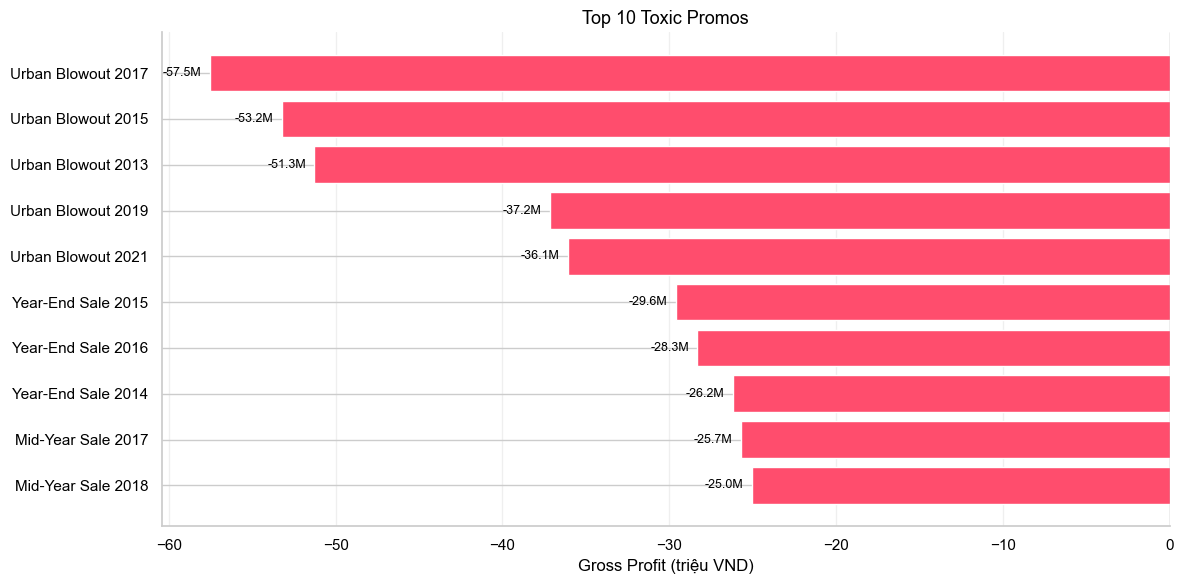

In [46]:
top10_loss = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit').head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
top10_plot = top10_loss.set_index('promo_name')['gross_profit'] / 1e6
colors = [ACCENT if v < 0 else OK for v in top10_plot]
bars = ax.barh(top10_plot.index, top10_plot.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, top10_plot.values):
    ax.text(val - 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:,.1f}M', va='center', ha='right', color='black', fontsize=9)
ax.set_title('Top 10 Toxic Promos', color='black', fontsize=13)
ax.set_xlabel('Gross Profit (triệu VND)', color='black')
ax.tick_params(colors='black')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top10_toxic_promos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [47]:
promo_meta = df_promotions[['promo_id','promo_type','discount_value','stackable_flag','min_order_value']]

items_type = items.merge(promo_meta,
                         left_on='promo_id', right_on='promo_id', how='left')

type_summary = (
    items_type[items_type['promo_flag']==1]
    .groupby('promo_type').agg(
        num_items     = ('order_id',        'size'),
        net_revenue   = ('net_revenue',     'sum'),
        discount_sum  = ('discount_amount', 'sum'),
        gross_profit  = ('gross_profit',    'sum'),
        avg_disc_rate = ('discount_rate',   'mean'),
    ).assign(
        margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
        share_pct  = lambda d: d['num_items'] / d['num_items'].sum()
    )
)
print('=== PROMO TYPE COMPARISON ===')
type_summary.style.format({
    'num_items':'{:,.0f}','net_revenue':'{:,.0f}','discount_sum':'{:,.0f}',
    'gross_profit':'{:,.0f}','avg_disc_rate':'{:.2%}',
    'margin_pct':'{:.2%}','share_pct':'{:.2%}'
}).applymap(lambda x: 'color: #ff4d6d' if isinstance(x,float) and x<0 else '',
            subset=['gross_profit','margin_pct'])

=== PROMO TYPE COMPARISON ===


,num_items,net_revenue,discount_sum,gross_profit,avg_disc_rate,margin_pct,share_pct
promo_type,,,,,,,
fixed,"20,950","371,747,191","4,726,550","-235,257,291",1.59%,-63.28%,7.58%
percentage,"255,366","4,314,083,021","744,880,770","-442,339,348",15.35%,-10.25%,92.42%


Fixed promotion nên bị khai tử vì không mang lại hiệu quả đáng kể, dù được áp dụng trên ít items (1/10 so vớ percentage) nhưng biên lợi nhuận lại âm gấp 6 lần so với percentage promotion

> ### Customer segmentation

*Phân loại customer:*
  - Full-price Only: Chưa từng sử dụng KM khi mua hàng
  - Cherry-picker: Chỉ mua hàng khi có KM (không có đơn nào full-price)
  - Mixed.Loyal: Dùng khuyến mãi khi có dịp
  - Promo-leaning: Thường mua có KM nhiều hơn

In [48]:
def classify(row):
    if row['promo_orders'] == 0:
        return 'Full-price Only'
    elif row['fullprice_orders'] == 0:
        return 'Cherry-picker (Promo Only)'
    elif row['promo_orders'] >= row['fullprice_orders']:
        return 'Promo-leaning'   
    else:
        return 'Mixed / Loyal'  

In [49]:
cust_orders = items.rename(columns={'segment': 'prod_segment'}).copy()

cust_orders['customer_id'] = cust_orders['customer_id'].astype(int)

cust_profile = (
    cust_orders.groupby('customer_id').agg(
        total_orders  = ('order_id',   pd.Series.nunique),
        promo_orders  = ('promo_flag', 'sum'),
    )
    .assign(fullprice_orders = lambda d: d['total_orders'] - d['promo_orders'])
    .reset_index()
)

cust_profile['customer_id'] = cust_profile['customer_id'].astype(int)
cust_profile['cust_segment'] = cust_profile.apply(classify, axis=1)

In [50]:
seg_revenue = (
    cust_orders.merge(cust_profile[['customer_id','cust_segment']], on='customer_id', how='left')
    .groupby('cust_segment')
    .agg(
        net_revenue   = ('net_revenue',  'sum'),
        gross_profit  = ('gross_profit', 'sum'),
        num_customers = ('customer_id',  pd.Series.nunique),
    )
    .assign(
        rev_per_cust    = lambda d: d['net_revenue']  / d['num_customers'],
        profit_per_cust = lambda d: d['gross_profit'] / d['num_customers'],
        margin_pct      = lambda d: d['gross_profit'] / d['net_revenue'],
    )
)

seg_revenue.style.format({
    'net_revenue':    '{:,.0f}', 'gross_profit':   '{:,.0f}',
    'num_customers':  '{:,.0f}', 'rev_per_cust':   '{:,.0f}',
    'profit_per_cust':'{:,.0f}', 'margin_pct':     '{:.2%}'
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x < 0 else '',
       subset=['gross_profit', 'margin_pct', 'profit_per_cust'])

,net_revenue,gross_profit,num_customers,rev_per_cust,profit_per_cust,margin_pct
cust_segment,,,,,,
Cherry-picker (Promo Only),"343,821,869","-34,783,176","11,268","30,513","-3,087",-10.12%
Full-price Only,"1,078,635,395","217,324,885","22,835","47,236","9,517",20.15%
Mixed / Loyal,"9,440,959,131","1,074,783,428","30,270","311,892","35,507",11.38%
Promo-leaning,"4,817,452,871","260,093,610","25,873","186,196","10,053",5.40%


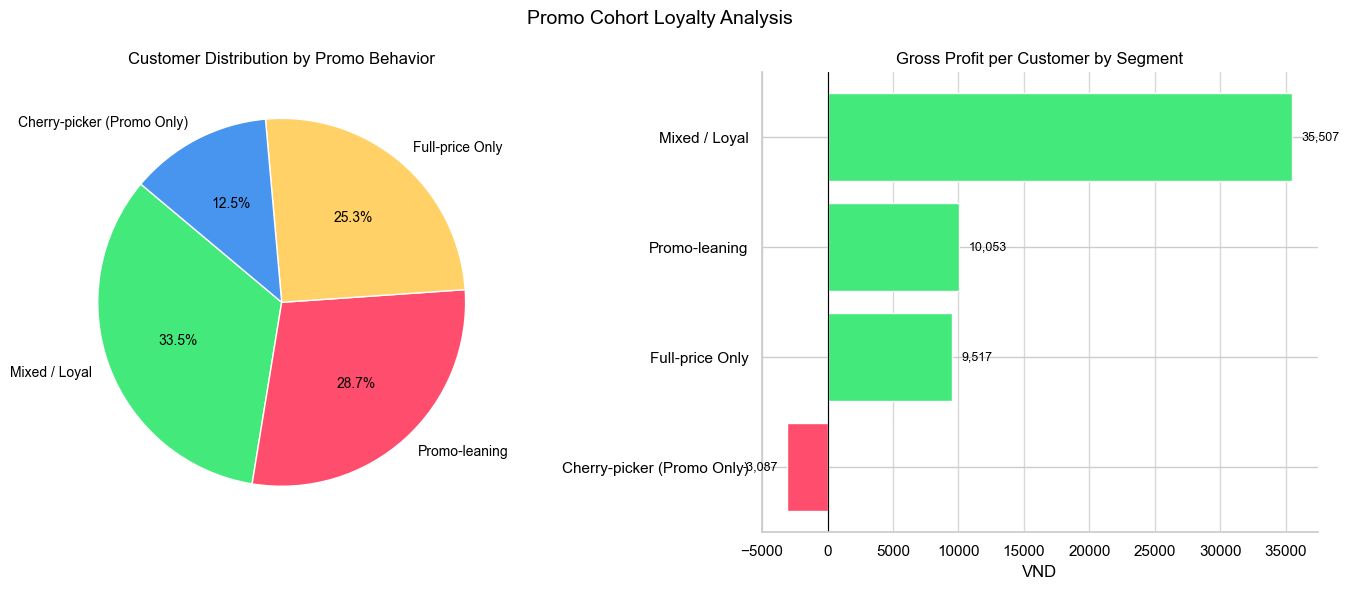

In [51]:
seg_counts = cust_profile['cust_segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
fig.suptitle('Promo Cohort Loyalty Analysis', color='black', fontsize=14)

# Pie
ax = axes[0]
pie_colors = [OK, ACCENT, YELLOW, BLUE]
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=pie_colors[:len(seg_counts)],
    startangle=140, textprops={'color':'black', 'fontsize':10}
)
ax.set_title('Customer Distribution by Promo Behavior', color='black')

# Profit per customer bar
ax2 = axes[1]
ppc = seg_revenue['profit_per_cust'].sort_values()
bar_c = [OK if v > 0 else ACCENT for v in ppc]
bars = ax2.barh(ppc.index, ppc.values, color=bar_c)
ax2.set_facecolor('white')
ax2.axvline(0, color='black', lw=0.8)
ax2.tick_params(colors='black')
ax2.xaxis.label.set_color('black')
ax2.title.set_color('black')
for bar, val in zip(bars, ppc.values):
    x_pos = val + (ppc.max() * 0.02) if val >= 0 else val - (ppc.max() * 0.02)
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', ha=ha, color='black', fontsize=9)
ax2.set_title('Gross Profit per Customer by Segment', color='black')
ax2.set_xlabel('VND')
ax2.grid(axis='x', alpha=0.3, color='gray')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('cohort_loyalty.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

1. Cherry-picker đang được doanh nghiệp "trợ cấp" — 11,268 khách này tạo ra -34.7M gross profit, tức là doanh nghiệp đang mất trung bình 3,087 VND cho mỗi lần họ mua hàng.
2. Full-price Only margin cao nhất (20.15%) nhưng rev/cust thấp — họ trung thành và profitable nhưng mua ít. Đây là nhóm cần được nurture, không phải chạy KM vào.
3. Mixed/Loyal là nhóm vàng — revenue/cust cao nhất (311,892), profit/cust cao nhất (35,507). Họ mua cả có và không có KM — Khuyến mãi với nhóm này ko phải là yếu tố họ quyết định mua hàngvì họ vẫn quay lại mua full-price.
Kết luận: Khuyến mãi đang thu hút sai đối tượng khách hàng — kéo Cherry-picker vào nhưng ko thể khiến họ họ thành Mixed/Loyal. Có thể thiết kế khuyến mãi có điều kiện (ví dụ: chỉ áp dụng cho khách đã có ít nhất 1 đơn chưa có khuyến mãi) để lọc bớt Cherry-picker.

In [52]:
cherry_dist = df_customers.merge(
    cust_profile[['customer_id','cust_segment']], on='customer_id'
).groupby(['acquisition_channel','cust_segment'])['customer_id'].count().unstack()
cherry_dist['total'] = cherry_dist.sum(axis=1)
cherry_dist['cherry_pct'] = (
    cherry_dist['Cherry-picker (Promo Only)'] /
    cherry_dist['total'] 
)
cherry_dist[['Cherry-picker (Promo Only)','cherry_pct', 'total']].style.format({
    'cherry_pct':    '{:.2%}',
    'total':     '{:.0f}'
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x < 0 else '')
#cherry_dist[['cherry_pct', 'total']]

cust_segment,Cherry-picker (Promo Only),cherry_pct,total
acquisition_channel,,,
direct,915,12.47%,7337
email_campaign,1399,12.85%,10886
organic_search,3333,12.37%,26950
paid_search,2232,12.40%,17999
referral,1166,12.85%,9072
social_media,2223,12.35%,18002


Cherry-picker chiếm ~12–13% ở tất cả các kênh và không bị ảnh hưởng bởi acquisition channel. Điều này cho thấy đây là một hành vi khách hàng cố hữu, không phải do marketing channel gây ra. Vì vậy, chiến lược nên tập trung vào thiết kế khuyến mãi và pricing thay vì tối ưu kênh

In [53]:
# Return count theo promo_flag
returns_promo = df_returns.merge(
    items[['order_id','promo_flag']].drop_duplicates('order_id'),  
    on='order_id', how='left'
)

return_counts = returns_promo.groupby('promo_flag')['return_id'].count()

order_counts = items.groupby('promo_flag')['order_id'].nunique()

return_rate = return_counts / order_counts

print('=== RETURN RATE: Promo vs Non-Promo ===')
result = pd.DataFrame({
    'num_returns':  return_counts,
    'num_orders':   order_counts,
    'return_rate':  return_rate,
}).rename(index={0: 'No Promo', 1: 'Promo'})

result.style.format({
    'num_returns': '{:,.0f}',
    'num_orders':  '{:,.0f}',
    'return_rate': '{:.2%}',
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x > 0.1 else '', 
       subset=['return_rate'])

=== RETURN RATE: Promo vs Non-Promo ===


,num_returns,num_orders,return_rate
promo_flag,,,
No Promo,"24,512","398,972",6.14%
Promo,"15,427","248,242",6.21%


Tỷ lệ trả hàng ở cả nhóm dùng khuyến mãi và không dùng khuyến mãi tương đương nhau nên lý do trả hàng không đến từ các đợt khuyến mãi mà do chất lượng sản phẩm hoặc nguyên nhân nào từ chính sản phẩm